# 3 Photon X Gate at Protection!

Using the same simulation procedure, I should be able to see a three photon drive at all the appropriate frequencies for a rabi. The exact example will likely be something like 0->5->4->1. In this case, since 0-5 and 4-1 have the same splitting, it really only needs two unique tones (~ omega1^2*omega2)

## Workflows

### Abstracted Workflow

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('/Users/thomasersevim/QNL/2q_gridium/')
import yaml

from Circuit_Objs.qchard_idealgridium import *
from Circuit_Objs.qchard_fluxonium import *
from Circuit_Objs.qchard_transmon import *
from Circuit_Objs.qchard_coupobj import *
from Circuit_Objs.qchard_evolgates import *
from workflow_funcs import *

#### IdealGridium - Soft

In [ ]:
gridium = IdealGridium(**soft_IdealGridium_params, **std_IdealGridium_sim_params)
gridium.nlev = 8

pulse_path1 = 'yamls/pulses/idealgridium_soft_d1.yaml'
pulse_path2 = 'yamls/pulses/idealgridium_soft_d2.yaml'

fig = solve_two_photon_drive(gridium, pulse_path1=pulse_path1, pulse_path2=pulse_path2, n_shown_states=3)
fig.show()

It seems as if the rate limiting step for simulations that have high ending fidelity is actually simulating the propegator for all combinations of levels (typically 10x10). This does not seem to meaningfully change the graphs, so for trial simulations, truncated nlevs seems to be appropriate. For very complex/large qubit simulations, best practice is to first simulate the eigenvectors/eigenvalues before then saving the object. This saves sucessive solve times for later.



### Modular Workflow

When you want to get more in the weeds. Basically the contents of solve_coupled_qubits

#### IdealGridium -- Soft

Pulse 1 targeting transition 0 to 5: 6.680 GHz
Drive detuning: 0
Pulse 2 targeting transition 0 to 5: 6.680 GHz
Drive detuning: 0


  0%|          | 0/80 [00:00<?, ?it/s]

** Final values **

Diagonal elements of the evolution operator (amplitudes and phases with respect to E*t in units of pi)


TypeError: operand 'Qobj' does not support ufuncs (__array_ufunc__=None)

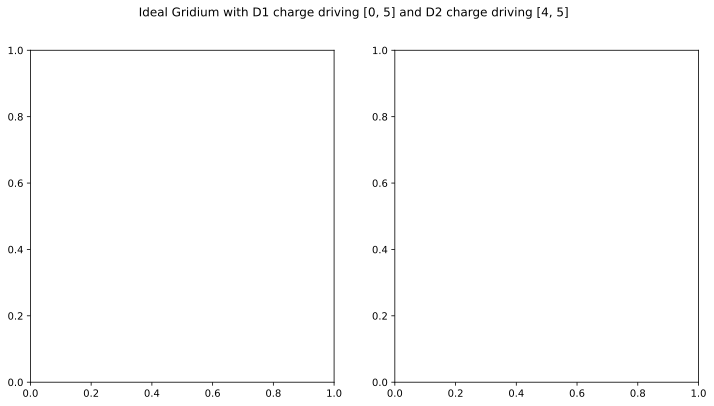

In [1]:
import sys
sys.path.append('Users/thomasersevim/anaconda3')
sys.path.append('/Users/thomasersevim/QNL/2q_gridium/')

import yaml
import qutip as qt
# qt.settings.core["auto_tidyup_atol] = 1e-18

from Circuit_Objs.qchard_idealgridium import *
from Circuit_Objs.qchard_fluxonium import *
from Circuit_Objs.qchard_transmon import *
from workflow_funcs import *

pulse_path1 = 'yamls/pulses/idealgridium_soft_d1.yaml'
pulse_path2 = 'yamls/pulses/idealgridium_soft_d2.yaml'

with open(pulse_path1, 'r') as f:
    pulse_cfg1_dict = yaml.safe_load(f)
    pulse_cfg1 = PulseConfig(**pulse_cfg1_dict)

with open(pulse_path2, 'r') as f:
    pulse_cfg2_dict = yaml.safe_load(f)
    pulse_cfg2 = PulseConfig(**pulse_cfg2_dict)

gridium = IdealGridium(**soft_IdealGridium_params, **std_IdealGridium_sim_params)
gridium.nlev = 8
gridium.nlev_lc = 100

qubit = gridium
n_shown_states = 3

qubit = load_qubit(qubit)
state_qubit_state(qubit, pulse_cfg1, pulse_cfg1)
t_points, U_t = solve(qubit, pulse_cfg1, pulse_cfg2, solve_method='propagator', mute=False)
fig = visualize_state_propagation(qubit, pulse_cfg1, pulse_cfg2, t_points, U_t, n_shown_states=n_shown_states)

In [2]:
psis = gridium.eigvecs()

In [20]:
vec_qobj = qt.Qobj(psis.reshape(8, 1))  # make it a column vector
result = U_t[0] * vec_qobj

TypeError: must be real number, not Qobj

In [ ]:
U_t[0]

TypeError: operand 'Qobj' does not support ufuncs (__array_ufunc__=None)

In [5]:
# qubit.n().check_herm()
import numpy as np
test = qubit.n()/np.abs(qubit.n_ij(pulse_cfg1.targeted_drive[0], pulse_cfg1.targeted_drive[1]))
test.check_herm()

True

#### SCQTransmon - Hard IdealGridium

In [4]:
import sys
sys.path.append('Users/thomasersevim/anaconda3')
sys.path.append('/Users/thomasersevim/QNL/2q_gridium/')

import yaml

from Circuit_Objs.qchard_idealgridium import *
from Circuit_Objs.qchard_fluxonium import *
from Circuit_Objs.qchard_transmon import *
from workflow_funcs import *

pulse_path = 'yamls/pulses/scqtransmon_idealgridium_hard.yaml'
syscfg_path = 'yamls/syscfgs/scqtransmon_idealgridium_hard.yaml'

with open(pulse_path, 'r') as f:
    data = yaml.safe_load(f)
    pulse_cfg = PulseConfig(**data)

with open(syscfg_path, 'r') as f:
    data = yaml.safe_load(f)
    system_cfg = SystemConfig(**data)
    del data

gridium = IdealGridium(**hard_IdealGridium_params, **std_IdealGridium_sim_params)
transmon = SCQTransmon(0.3,15,0,8,20)
gridium.nlev_lc = 1000
gridium.nlev = 8
transmon.nlev = 8

qubitA = transmon
qubitB = gridium

n_shown_states = 3

qubitA, qubitB = load_qubits(qubitA, qubitB)
qubitA, qubitB = scale_qubitA_transition(qubitA, qubitB, system_cfg)
system = couple_qubits(qubitA, qubitB, system_cfg, pulse_cfg, mute=False)
t_points, U_t, phase_accum, fidelity = solve(system, pulse_cfg, system_cfg, solve_method='propagator', mute=False)
fig = visualize_state_propagation(system, system_cfg, t_points, U_t, phase_accum, fidelity, n_shown_states=n_shown_states)

FileNotFoundError: [Errno 2] No such file or directory: 'yamls/pulses/scqtransmon_idealgridium_hard.yaml'

#### SCQTransmon - Hard IdealGridium

In [ ]:
import sys
sys.path.append('Users/thomasersevim/anaconda3')
sys.path.append('/Users/thomasersevim/QNL/2q_gridium/')

import yaml

from Circuit_Objs.qchard_idealgridium import *
from Circuit_Objs.qchard_fluxonium import *
from Circuit_Objs.qchard_transmon import *
from workflow_funcs import *

pulse_path = 'yamls/pulses/scqtransmon_idealgridium_hard.yaml'
syscfg_path = 'yamls/syscfgs/scqtransmon_idealgridium_hard.yaml'

with open(pulse_path, 'r') as f:
    data = yaml.safe_load(f)
    pulse_cfg = PulseConfig(**data)

with open(syscfg_path, 'r') as f:
    data = yaml.safe_load(f)
    system_cfg = SystemConfig(**data)
    del data

gridium = IdealGridium(**hard_IdealGridium_params, **std_IdealGridium_sim_params)
transmon = SCQTransmon(0.3,15,0,8,20)
gridium.nlev_lc = 1000
gridium.nlev = 8
transmon.nlev = 8

qubitA = transmon
qubitB = gridium

n_shown_states = 3

qubitA, qubitB = load_qubits(qubitA, qubitB)
qubitA, qubitB = scale_qubitA_transition(qubitA, qubitB, system_cfg)
system = couple_qubits(qubitA, qubitB, system_cfg, pulse_cfg, mute=False)
t_points, U_t, phase_accum, fidelity = solve(system, pulse_cfg, system_cfg, solve_method='propagator', mute=False)
fig = visualize_state_propagation(system, system_cfg, t_points, U_t, phase_accum, fidelity, n_shown_states=n_shown_states)

Transmon uncoupled, prescaled transition is 5.7 GHz
Ideal Gridium uncoupled intended resonant transition is 0.4 GHz
Transmon uncoupled, postscaled transition is 0.4 GHz

Intended detuning between 00-03 and 10-13 (2nd minus 1st): 1.105 MHz
Comparative detuning between 01-02 and 11-12 (2nd minus 1st): -0.775 MHz
Relative detuning is -1.880 MHz (comparitive - intended)
Transition to drive: 00 - 03 with frequency 2.9832 GHz
Comparative transition: 01 - 02 with frequency 2.983141 GHz

Drive frequency: 2.9837 GHz
Drive amplitude scale factor: 1.0000


  0%|          | 0/80 [00:00<?, ?it/s]

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
 /Users/thomasersevim/anaconda3/envs/gkp_qchard/lib/python3.14/site-packages/scipy/integrate/_ode.py: 418

IntegratorException: Excess work done on this call. Try to increasing the nsteps parameter in the Options class

## Saving Diagonalized Objects

For speed in later use

In [ ]:
# gridium = IdealGridium(**soft_IdealGridium_params, **std_IdealGridium_sim_params)
# gridium.nlev = 10
# gridium.levels(eigvecs=True)
# gridium.save_obj('/Users/thomasersevim/QNL/2q_gridium/etc/qubits/')

# fluxonium = Fluxonium(**fluxonium_params, **std_fluxonium_sim_params)
# fluxonium.nlev = 10
# fluxonium.levels(eigvecs=True)
# fluxonium.save_obj('/Users/thomasersevim/QNL/2q_gridium/etc/qubits/')

# qubitA.levels(eigvecs=True)
# qubitA.save_obj('/Users/thomasersevim/QNL/2q_gridium/etc/qubits/')
qubitB.levels(eigvecs=True)
qubitB.save_obj('/Users/thomasersevim/QNL/2q_gridium/etc/qubits/')

## Testing

In [ ]:
transmon = SCQTransmon(0.3, 15, 0, 6, 8)
transmon.nlev_lc = 1000
transmon.nlev = 20
print(transmon.transition_energies())